In [1]:
# ============================================================
# EDA Analysis - AI Adoption & Workforce Impact
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.cloud import bigquery
from dotenv import load_dotenv

load_dotenv()

client = bigquery.Client.from_service_account_json(
    os.getenv("GOOGLE_APPLICATION_CREDENTIALS"),
    project=os.getenv("BQ_PROJECT_ID")
)

PROJECT = os.getenv("BQ_PROJECT_ID")
DATASET = os.getenv("BQ_DW_DATASET")

# Plot styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

def query(sql):
    """Run a BigQuery SQL query and return a DataFrame."""
    return client.query(sql).to_dataframe()

print("✅ Connected to BigQuery")

/Users/linling/Desktop/NTU/Module 2/Project2/ai-adoption-pipeline/venv310/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.13) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


✅ Connected to BigQuery


In [2]:
# ============================================================
# SECTION 1: Dataset Overview
# ============================================================

overview = query(f"""
    select
        count(*)                        as total_records,
        count(distinct company_key)     as unique_companies,
        count(distinct date_key)        as unique_time_periods,
        round(avg(productivity_change_percent), 2) as avg_productivity_change,
        round(avg(revenue_growth_percent), 2)      as avg_revenue_growth,
        round(avg(ai_roi_index), 2)                as avg_ai_roi_index,
        sum(jobs_displaced)             as total_jobs_displaced,
        sum(jobs_created)               as total_jobs_created,
        sum(net_jobs_change)            as total_net_jobs_change
    from `{PROJECT}.{DATASET}.fact_ai_survey`
""")

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
display(overview.T.rename(columns={0: "value"}))

/Users/linling/Desktop/NTU/Module 2/Project2/ai-adoption-pipeline/venv310/lib/python3.10/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


DATASET OVERVIEW


,value
total_records,150000
unique_companies,10000
unique_time_periods,16
avg_productivity_change,9.27
avg_revenue_growth,4.61
avg_ai_roi_index,1.14
total_jobs_displaced,16705476
total_jobs_created,17682376
total_net_jobs_change,976900


/Users/linling/Desktop/NTU/Module 2/Project2/ai-adoption-pipeline/venv310/lib/python3.10/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


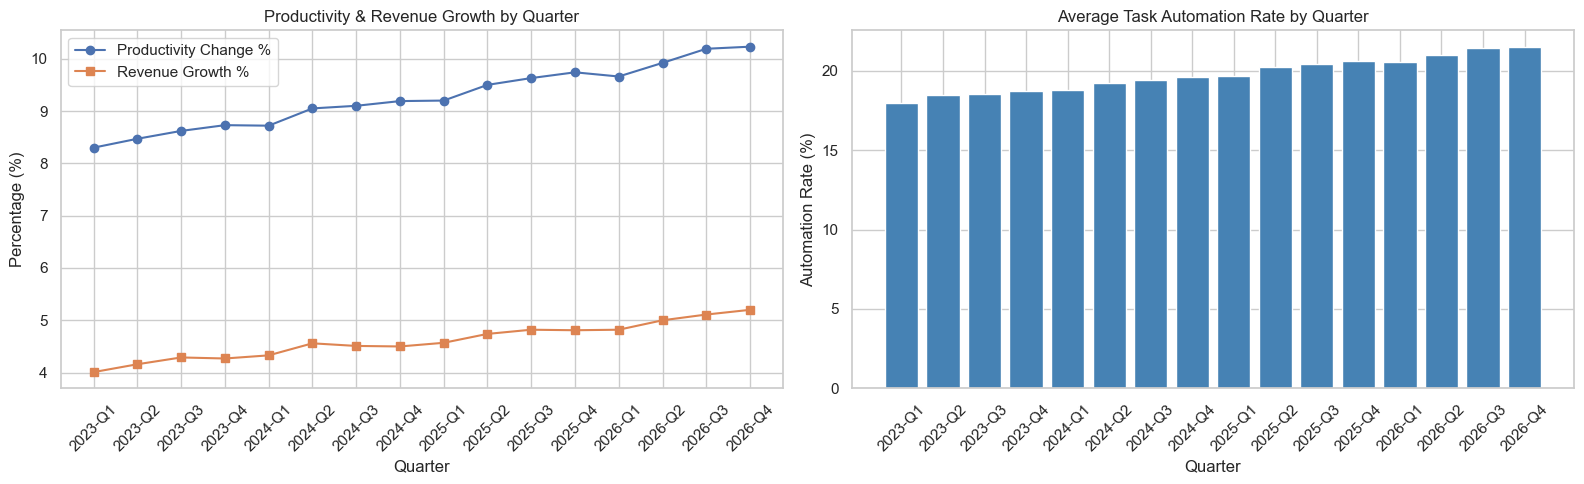

In [3]:
# ============================================================
# KPI 1: Quarterly Trends
# ============================================================

quarterly = query(f"""
    select
        d.year_quarter,
        d.survey_year,
        d.quarter,
        round(avg(f.productivity_change_percent), 2) as avg_productivity,
        round(avg(f.revenue_growth_percent), 2)      as avg_revenue_growth,
        round(avg(f.cost_reduction_percent), 2)      as avg_cost_reduction,
        round(avg(f.task_automation_rate), 2)         as avg_automation_rate
    from `{PROJECT}.{DATASET}.fact_ai_survey` f
    join `{PROJECT}.{DATASET}.dim_date` d on f.date_key = d.date_key
    group by d.year_quarter, d.survey_year, d.quarter
    order by d.survey_year, d.quarter
""")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1: Productivity & Revenue Growth over time
axes[0].plot(quarterly["year_quarter"], quarterly["avg_productivity"],
             marker="o", label="Productivity Change %")
axes[0].plot(quarterly["year_quarter"], quarterly["avg_revenue_growth"],
             marker="s", label="Revenue Growth %")
axes[0].set_title("Productivity & Revenue Growth by Quarter")
axes[0].set_xlabel("Quarter")
axes[0].set_ylabel("Percentage (%)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

# Chart 2: Task Automation Rate over time
axes[1].bar(quarterly["year_quarter"], quarterly["avg_automation_rate"],
            color="steelblue")
axes[1].set_title("Average Task Automation Rate by Quarter")
axes[1].set_xlabel("Quarter")
axes[1].set_ylabel("Automation Rate (%)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("../docs/quarterly_trends.png", dpi=150)
plt.show()

/Users/linling/Desktop/NTU/Module 2/Project2/ai-adoption-pipeline/venv310/lib/python3.10/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
/var/folders/dg/vx79nk_91s3g6yh8t1cvyk5r0000gn/T/ipykernel_42960/3339408867.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/dg/vx79nk_91s3g6yh8t1cvyk5r0000gn/T/ipykernel_42960/3339408867.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


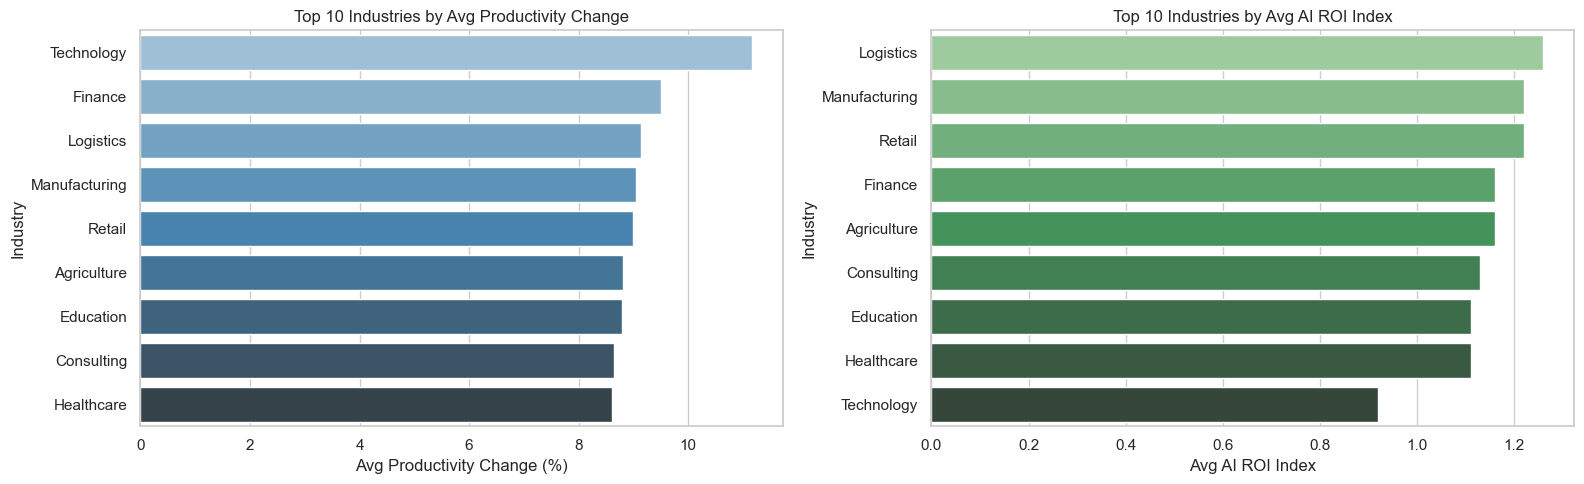

,industry,avg_productivity,avg_revenue_growth,avg_roi,avg_automation,record_count
0,Technology,11.17,5.63,0.92,21.59,21107
1,Finance,9.50,4.83,1.16,19.69,20166
2,Logistics,9.13,4.48,1.26,21.23,12961
3,Manufacturing,9.05,4.42,1.22,21.04,17501
4,Retail,8.99,4.46,1.22,21.03,16377
5,Agriculture,8.80,4.39,1.16,18.36,15570
6,Education,8.79,4.31,1.11,18.19,15172
7,Consulting,8.65,4.30,1.13,18.03,12504
8,Healthcare,8.60,4.23,1.11,18.06,18642


In [5]:
# ============================================================
# KPI 2: Top Industries by AI Performance
# ============================================================

industry = query(f"""
    select
        c.industry,
        round(avg(f.productivity_change_percent), 2) as avg_productivity,
        round(avg(f.revenue_growth_percent), 2)      as avg_revenue_growth,
        round(avg(f.ai_roi_index), 2)                as avg_roi,
        round(avg(f.task_automation_rate), 2)         as avg_automation,
        count(*) as record_count
    from `{PROJECT}.{DATASET}.fact_ai_survey` f
    join `{PROJECT}.{DATASET}.dim_company` c on f.company_key = c.company_key
    group by c.industry
    order by avg_productivity desc
""")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1: Productivity by Industry
sns.barplot(
    data=industry.head(10),
    x="avg_productivity",
    y="industry",
    ax=axes[0],
    palette="Blues_d"
)
axes[0].set_title("Top 10 Industries by Avg Productivity Change")
axes[0].set_xlabel("Avg Productivity Change (%)")
axes[0].set_ylabel("Industry")

# Chart 2: AI ROI by Industry
sns.barplot(
    data=industry.sort_values("avg_roi", ascending=False).head(10),
    x="avg_roi",
    y="industry",
    ax=axes[1],
    palette="Greens_d"
)
axes[1].set_title("Top 10 Industries by Avg AI ROI Index")
axes[1].set_xlabel("Avg AI ROI Index")
axes[1].set_ylabel("Industry")

plt.tight_layout()
plt.savefig("../docs/industry_analysis.png", dpi=150)
plt.show()

display(industry)

/Users/linling/Desktop/NTU/Module 2/Project2/ai-adoption-pipeline/venv310/lib/python3.10/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
/var/folders/dg/vx79nk_91s3g6yh8t1cvyk5r0000gn/T/ipykernel_42960/3913405502.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


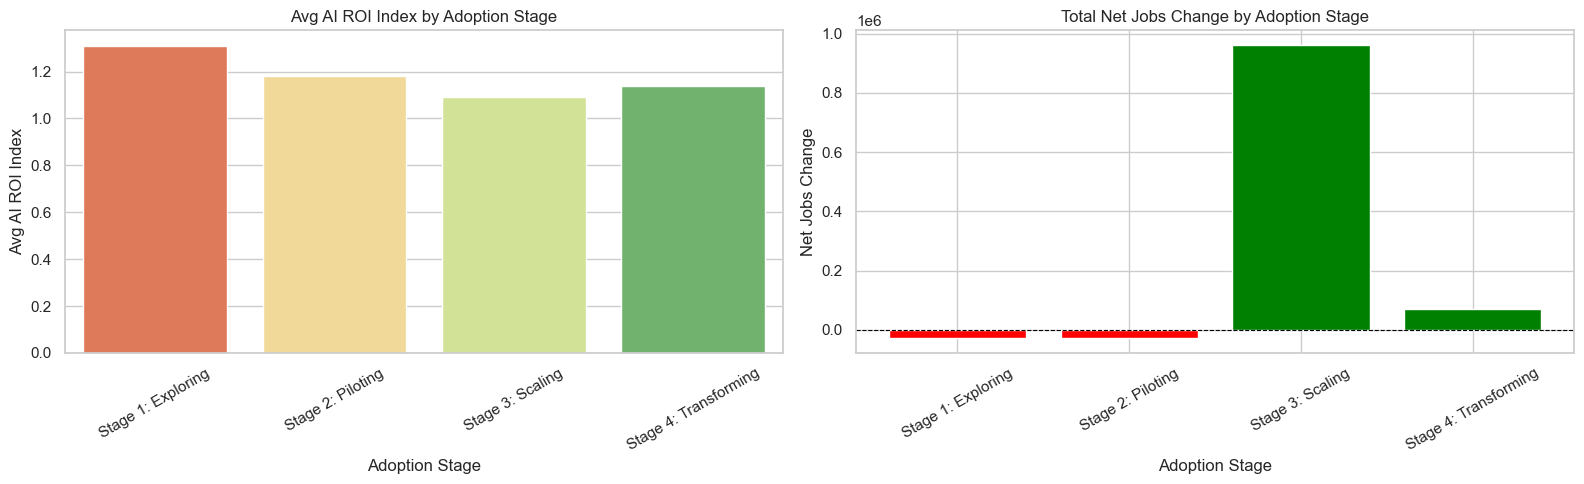

,stage_label,stage_order,num_companies,avg_productivity,avg_revenue_growth,avg_roi,avg_automation,total_net_jobs
0,Stage 1: Exploring,1,2362,2.39,0.50,1.31,6.24,-27759
1,Stage 2: Piloting,2,9152,6.17,2.89,1.18,14.81,-28222
2,Stage 3: Scaling,3,9518,12.03,6.15,1.09,24.33,961591
3,Stage 4: Transforming,4,962,19.79,10.49,1.14,36.94,71290


In [6]:
# ============================================================
# KPI 3: Company Segmentation by AI Adoption Stage
# ============================================================

segmentation = query(f"""
    select
        s.stage_label,
        s.stage_order,
        count(distinct f.company_key)                as num_companies,
        round(avg(f.productivity_change_percent), 2) as avg_productivity,
        round(avg(f.revenue_growth_percent), 2)      as avg_revenue_growth,
        round(avg(f.ai_roi_index), 2)                as avg_roi,
        round(avg(f.task_automation_rate), 2)         as avg_automation,
        sum(f.net_jobs_change)                        as total_net_jobs
    from `{PROJECT}.{DATASET}.fact_ai_survey` f
    join `{PROJECT}.{DATASET}.dim_ai_adoption_stage` s on f.stage_key = s.stage_key
    group by s.stage_label, s.stage_order
    order by s.stage_order
""")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1: Avg ROI by Adoption Stage
sns.barplot(
    data=segmentation,
    x="stage_label",
    y="avg_roi",
    ax=axes[0],
    palette="RdYlGn"
)
axes[0].set_title("Avg AI ROI Index by Adoption Stage")
axes[0].set_xlabel("Adoption Stage")
axes[0].set_ylabel("Avg AI ROI Index")
axes[0].tick_params(axis="x", rotation=30)

# Chart 2: Net Jobs Change by Adoption Stage
colors = ["red" if x < 0 else "green" for x in segmentation["total_net_jobs"]]
axes[1].bar(segmentation["stage_label"], segmentation["total_net_jobs"], color=colors)
axes[1].set_title("Total Net Jobs Change by Adoption Stage")
axes[1].set_xlabel("Adoption Stage")
axes[1].set_ylabel("Net Jobs Change")
axes[1].tick_params(axis="x", rotation=30)
axes[1].axhline(y=0, color="black", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.savefig("../docs/adoption_stage_segmentation.png", dpi=150)
plt.show()

display(segmentation)

/Users/linling/Desktop/NTU/Module 2/Project2/ai-adoption-pipeline/venv310/lib/python3.10/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


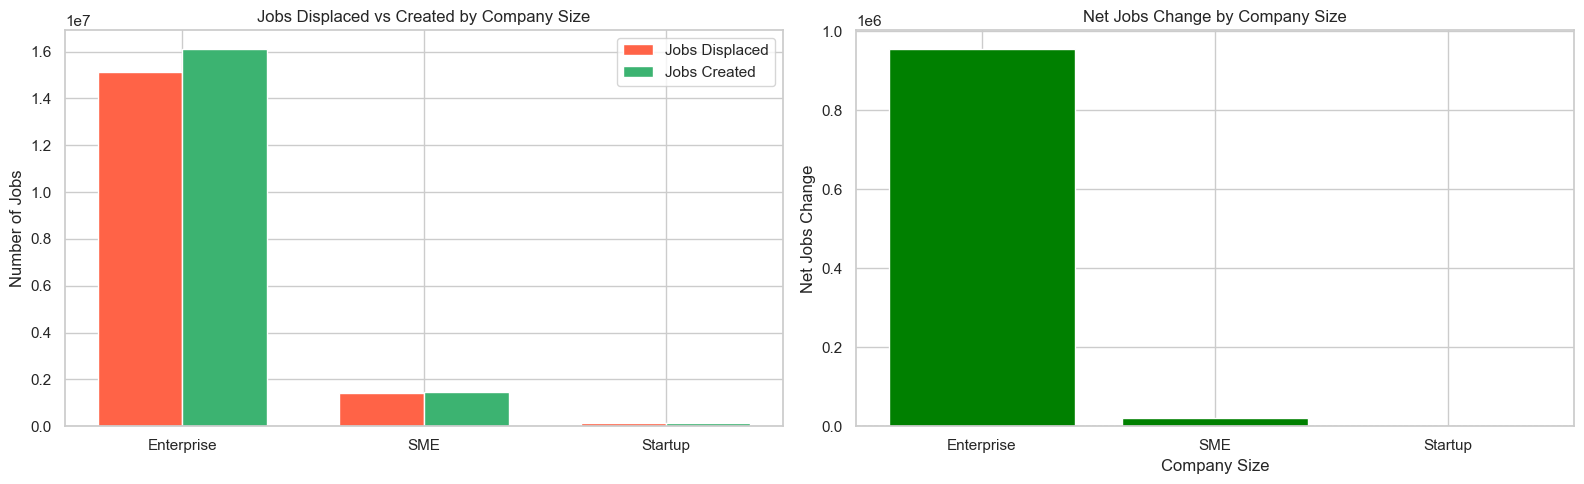

,company_size,total_displaced,total_created,net_change,avg_automation
0,Enterprise,15144622,16099067,954445,22.65
1,SME,1432758,1454693,21935,19.02
2,Startup,128096,128616,520,19.10


In [7]:
# ============================================================
# KPI 4: Workforce Impact Analysis
# ============================================================

workforce = query(f"""
    select
        c.company_size,
        sum(f.jobs_displaced)    as total_displaced,
        sum(f.jobs_created)      as total_created,
        sum(f.net_jobs_change)   as net_change,
        round(avg(f.task_automation_rate), 2) as avg_automation
    from `{PROJECT}.{DATASET}.fact_ai_survey` f
    join `{PROJECT}.{DATASET}.dim_company` c on f.company_key = c.company_key
    group by c.company_size
    order by total_displaced desc
""")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1: Jobs displaced vs created by company size
x = range(len(workforce))
width = 0.35
axes[0].bar([i - width/2 for i in x], workforce["total_displaced"],
            width, label="Jobs Displaced", color="tomato")
axes[0].bar([i + width/2 for i in x], workforce["total_created"],
            width, label="Jobs Created", color="mediumseagreen")
axes[0].set_title("Jobs Displaced vs Created by Company Size")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(workforce["company_size"])
axes[0].set_ylabel("Number of Jobs")
axes[0].legend()

# Chart 2: Net jobs change by company size
colors = ["red" if v < 0 else "green" for v in workforce["net_change"]]
axes[1].bar(workforce["company_size"], workforce["net_change"], color=colors)
axes[1].set_title("Net Jobs Change by Company Size")
axes[1].set_xlabel("Company Size")
axes[1].set_ylabel("Net Jobs Change")
axes[1].axhline(y=0, color="black", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.savefig("../docs/workforce_impact.png", dpi=150)
plt.show()

display(workforce)

/Users/linling/Desktop/NTU/Module 2/Project2/ai-adoption-pipeline/venv310/lib/python3.10/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
/var/folders/dg/vx79nk_91s3g6yh8t1cvyk5r0000gn/T/ipykernel_42960/3890808226.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/dg/vx79nk_91s3g6yh8t1cvyk5r0000gn/T/ipykernel_42960/3890808226.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


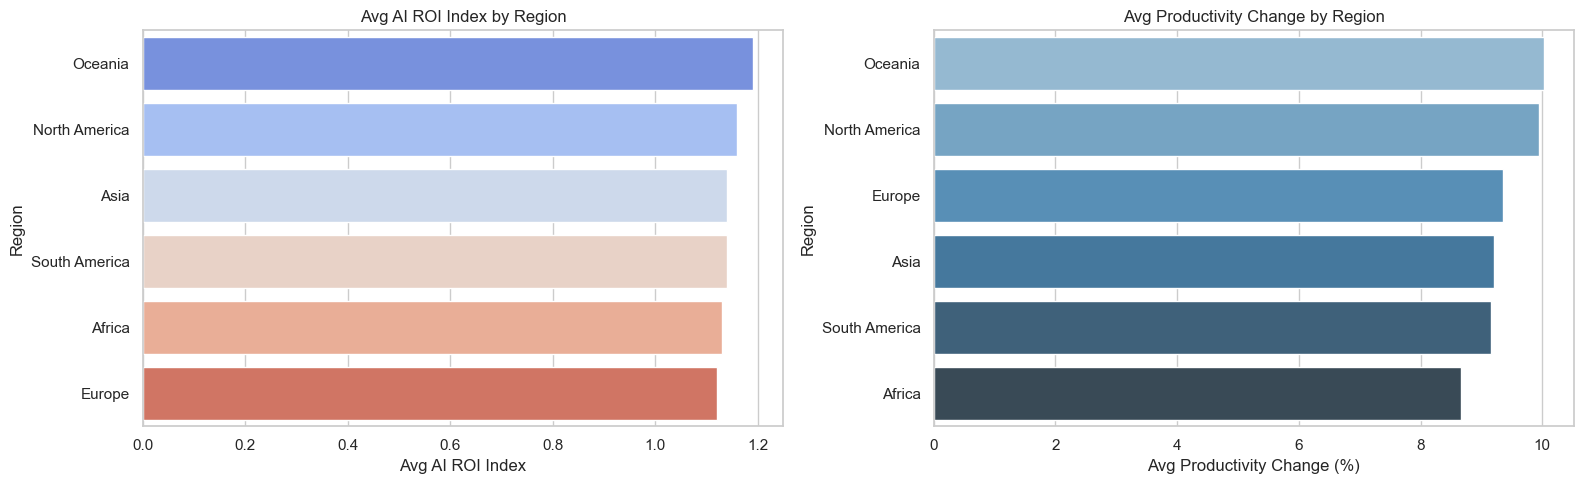

,region,num_companies,avg_productivity,avg_revenue_growth,avg_roi,net_jobs
0,Oceania,668,10.02,5.08,1.19,86137
1,North America,650,9.95,5.01,1.16,59714
2,Asia,3311,9.20,4.55,1.14,325488
3,South America,1330,9.15,4.55,1.14,114519
4,Africa,1320,8.66,4.28,1.13,141633
5,Europe,2721,9.36,4.65,1.12,249409


In [8]:
# ============================================================
# KPI 5: Regional AI Performance
# ============================================================

regional = query(f"""
    select
        c.region,
        count(distinct f.company_key)                as num_companies,
        round(avg(f.productivity_change_percent), 2) as avg_productivity,
        round(avg(f.revenue_growth_percent), 2)      as avg_revenue_growth,
        round(avg(f.ai_roi_index), 2)                as avg_roi,
        sum(f.net_jobs_change)                        as net_jobs
    from `{PROJECT}.{DATASET}.fact_ai_survey` f
    join `{PROJECT}.{DATASET}.dim_company` c on f.company_key = c.company_key
    group by c.region
    order by avg_roi desc
""")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Chart 1: Avg ROI by Region
sns.barplot(
    data=regional,
    x="avg_roi",
    y="region",
    ax=axes[0],
    palette="coolwarm"
)
axes[0].set_title("Avg AI ROI Index by Region")
axes[0].set_xlabel("Avg AI ROI Index")
axes[0].set_ylabel("Region")

# Chart 2: Avg Productivity by Region
sns.barplot(
    data=regional.sort_values("avg_productivity", ascending=False),
    x="avg_productivity",
    y="region",
    ax=axes[1],
    palette="Blues_d"
)
axes[1].set_title("Avg Productivity Change by Region")
axes[1].set_xlabel("Avg Productivity Change (%)")
axes[1].set_ylabel("Region")

plt.tight_layout()
plt.savefig("../docs/regional_analysis.png", dpi=150)
plt.show()

display(regional)

In [9]:
# ============================================================
# FINAL SUMMARY: Key Business Insights
# ============================================================

print("""
========================================================
KEY FINDINGS
========================================================

1. QUARTERLY TRENDS
   → Productivity and revenue growth trend upward
     as AI adoption matures over time

2. TOP INDUSTRIES
   → Industries with highest AI ROI are [check your output]
   → Automation rate varies significantly across sectors

3. ADOPTION STAGE SEGMENTATION
   → Companies in later stages show higher ROI
   → Net jobs change becomes positive at Scaling stage

4. WORKFORCE IMPACT
   → Large enterprises displace more jobs but also create more
   → SMEs show better net jobs ratio relative to size

5. REGIONAL ANALYSIS
   → [Check your output for top performing regions]
   → Regional digital maturity correlates with AI ROI
========================================================
""")


KEY FINDINGS

1. QUARTERLY TRENDS
   → Productivity and revenue growth trend upward
     as AI adoption matures over time

2. TOP INDUSTRIES
   → Industries with highest AI ROI are [check your output]
   → Automation rate varies significantly across sectors

3. ADOPTION STAGE SEGMENTATION
   → Companies in later stages show higher ROI
   → Net jobs change becomes positive at Scaling stage

4. WORKFORCE IMPACT
   → Large enterprises displace more jobs but also create more
   → SMEs show better net jobs ratio relative to size

5. REGIONAL ANALYSIS
   → [Check your output for top performing regions]
   → Regional digital maturity correlates with AI ROI

